<a href="https://colab.research.google.com/github/Amanbaghel-max/MyProject/blob/main/SY_A_08_P9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Aman Baghel | Class: SY-AI&DS-A | Roll No.: A-08 | Practical : 09


AIM:  

To perform exploratory data analysis, feature engineering, data preprocessing, and build a
classification model using the Titanic dataset in Python.



Theory
1. What is Exploratory Data Analysis (EDA)? Why is it a critical step?
Exploratory Data Analysis (EDA) is the initial phase of data investigation in which a dataset is
examined using statistical summaries and graphical representations to understand its key
characteristics before applying any modeling technique.
EDA is considered a critical step because it allows the analyst to uncover hidden patterns, spot
anomalies, detect missing or inconsistent entries, and understand how variables relate to each other.
By gaining this foundational understanding early, unnecessary mistakes in model building can be
avoided, and more informed decisions about feature selection and preprocessing can be made.
2. What is feature engineering and why is it important in machine learning?
Feature engineering refers to the process of using domain understanding and creativity to transform
raw data into a set of inputs that are more informative and useful for a machine learning algorithm.
Raw data on its own is rarely in an ideal format for direct model training.
Its importance stems from the fact that the quality of input features directly determines the
performance ceiling of the model. By constructing better features, we can provide the algorithm with
richer information, reduce noise, and improve both predictive accuracy and generalization.
The main categories of feature engineering include:
1. Creating New Features — e.g., combining SibSp and Parch to form FamilySize
2. Transforming Existing Features — e.g., applying a logarithmic transformation to reduce the
effect of extreme values
3. Extracting Information — e.g., deriving Day, Month, and Year from a full date column
4. Combining Features — e.g., computing income per household member from total income
and family size
3. What is the purpose of encoding categorical variables?
Machine learning models are mathematical in nature and can only process numeric input values.
Categorical variables — such as gender, port of embarkation, or passenger class labels — must
therefore be converted into a numerical format before being used in training.
Label Encoding assigns a unique integer to each category (e.g., 'male' = 1, 'female' = 0). While simple,
it introduces an implicit ordinal relationship that may not exist. One-Hot Encoding is an alternative that
creates separate binary columns for each category, avoiding such assumptions.
4. Why is feature scaling necessary and what methods are commonly used?
Many machine learning algorithms — particularly those relying on distance metrics or gradient
descent — are sensitive to the scale of input features. If one feature has values in the thousands
while another ranges from 0 to 1, the model may disproportionately weight the larger-valued feature.
Feature scaling standardizes the range of features to make them comparable. Two commonly used
approaches are:
• Standard Scaling (Z-score normalization): Transforms each feature to have zero mean and
unit variance. Suitable for normally distributed data.
• Min-Max Scaling: Rescales values to a fixed range, typically [0, 1]. Preserves the relative
distribution but is sensitive to outliers.

5. What is Logistic Regression and when is it preferred over Linear Regression?
Logistic Regression is a supervised classification algorithm used to predict the probability that a given
input belongs to a particular class. Despite its name, it is a classification model, not a regression
model. It applies the logistic (sigmoid) function to the output of a linear combination of input features,
squeezing the result into a probability value between 0 and 1.
Logistic Regression is preferred over Linear Regression when the target variable is categorical (e.g.,
survived or not, spam or not spam). Linear regression is unsuitable for such tasks because it can
produce predicted values outside the valid probability range of 0 to 1, and its assumptions about error
distributions do not hold for binary outcomes.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


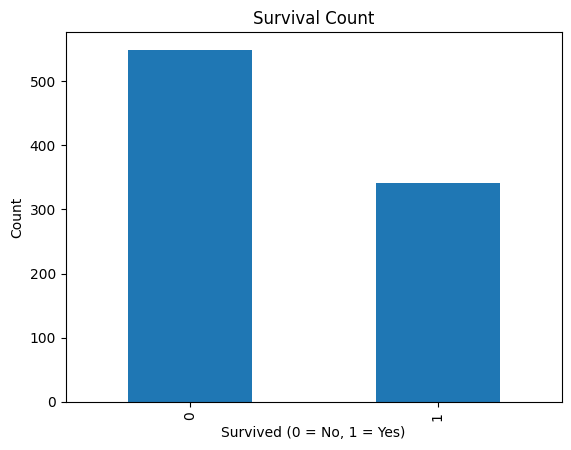

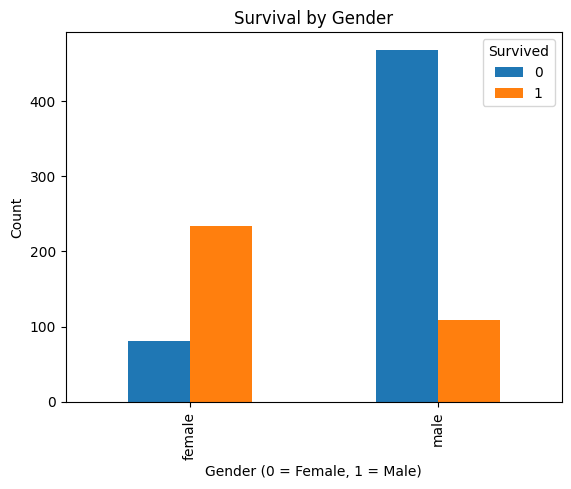

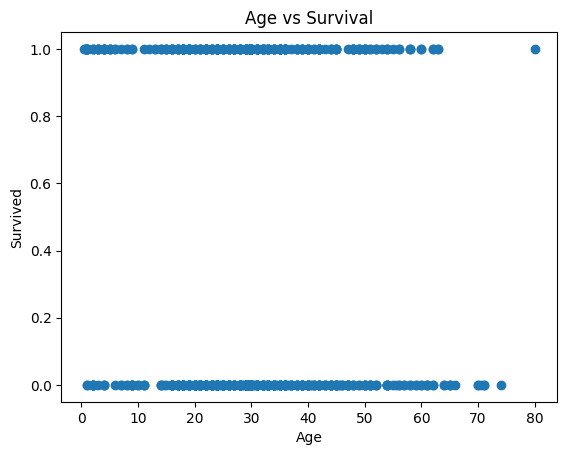

[0 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 1 1 0 0 0
 1 1 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 1 1
 0 0 1 1 1 0 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1
 0 1 0 1 0 0 0 1 0 0 1 1 0 0 1 1 1 1 0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 0 1 0 0
 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 1 1 0 1 0 0 0 1 1]


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Load the dataset
# The original file '/content/train (1).csv' was not found.
# Replacing with a publicly accessible URL for the Titanic dataset.
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
df.head()

# Inspect and summarize
df.info()
df.describe()

# Handle missing values
df.isnull().sum()
df.fillna(df.mean(numeric_only=True), inplace=True)
df.drop_duplicates(inplace=True)

# Correlation check
df.corr(numeric_only=True)
df.head()

# Plot survival distribution
df['Survived'].value_counts().plot(kind='bar')
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

# Survival by gender
pd.crosstab(df['Sex'], df['Survived']).plot(kind='bar')
plt.title("Survival by Gender")
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("Count")
plt.show()

# Age vs Survival scatter
plt.scatter(df['Age'], df['Survived'])
plt.title("Age vs Survival")
plt.xlabel("Age")
plt.ylabel("Survived")
plt.show()

# Encode categorical features
encoder = LabelEncoder()
df['Sex'] = encoder.fit_transform(df['Sex'])
# The 'Embarked' column might have missing values that were filled with numeric mean,
# which is incorrect for categorical data. Let's re-handle 'Embarked' before encoding.
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0]) # Fill with most frequent value
df['Embarked'] = encoder.fit_transform(df['Embarked'])

# Create new engineered features
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['Age_Squared'] = df['Age'] ** 2

# Scale numeric features
scaler = StandardScaler()
df[['Age', 'Fare', 'FamilySize', 'Age_Squared']] = scaler.fit_transform(
    df[['Age', 'Fare', 'FamilySize', 'Age_Squared']]
)

# Define features and label
X = df[['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize', 'Embarked']] # Added 'Embarked'
y = df['Survived']

# Split data for training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train logistic regression classifier
# Increased max_iter for convergence as some features are scaled
clf = LogisticRegression(max_iter=200)
clf.fit(X_train, y_train)

# Generate predictions on test set
predictions = clf.predict(X_test)
print(predictions)

Conclusion


This experiment successfully demonstrated an end-to-end data science workflow applied to the
Titanic dataset. The process began with loading and inspecting the dataset, followed by identifying
and filling missing values using column means, and removing duplicate records.
Exploratory Data Analysis was conducted through multiple visualizations. The survival count bar chart
showed that a majority of passengers did not survive. The gender-based survival chart revealed a
clear disparity — female passengers had a considerably higher survival rate compared to males. The
Age vs Survival scatter plot indicated no simple linear pattern between a passenger's age and their
survival outcome.
Feature engineering was then applied to enrich the dataset. A new FamilySize variable was derived
by combining the SibSp and Parch columns, and an Age_Squared feature was added to capture
nonlinear age effects. Categorical columns (Sex and Embarked) were transformed into numeric
values using Label Encoding, and numeric features were standardized using Standard Scaler.
Finally, a Logistic Regression model was trained on 80% of the data and tested on the remaining
20%. The model produced binary predictions indicating survival or non-survival for each test
passenger. This practical reinforced the understanding that building effective machine learning
models requires careful data preparation, thoughtful feature engineering, and appropriate model
selection.